<a href="https://colab.research.google.com/github/acorraleswork/acorraleswork.github.io/blob/main/Practice_Portfolio_Anime_Female_and_Males_Viewers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
marlesson_myanimelist_dataset_animes_profiles_reviews_path = kagglehub.dataset_download('marlesson/myanimelist-dataset-animes-profiles-reviews')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd# data processing, CSV file I/O (e.g. pd.read_csv)
import sqlite3
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
#anime_df=pd.read_csv('/Users/ace/Downloads/New Folder With Items/archive/animes.csv')
#users_df=pd.read_csv('/Users/ace/Downloads/New Folder With Items/archive/profiles.csv')

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
from kagglehub import KaggleDatasetAdapter

anime_df=pd.read_csv('/kaggle/input/datasets/marlesson/myanimelist-dataset-animes-profiles-reviews/animes.csv',nrows=50000)
user_df=pd.read_csv('/kaggle/input/datasets/marlesson/myanimelist-dataset-animes-profiles-reviews/profiles.csv',nrows=50000)
reviews_df=pd.read_csv('/kaggle/input/datasets/marlesson/myanimelist-dataset-animes-profiles-reviews/reviews.csv',nrows=50000)

conn = sqlite3.connect(':memory:')
anime_df.to_sql('anime_table', conn, index=False)
user_df.to_sql('users_table',conn, index= False)
reviews_df.to_sql('reviews_table',conn, index=False)

sql_query="""
/* select *
from  anime_table Limit 20*/
--Top 20 most watch by males
select
a.title,
sum(case when u.gender='Female' then 1 else 0 end) as Female_viewers,
sum(case when u.gender ='Male' then 1 else 0 end) as MaleViewer
FROM users_table u
join reviews_table r on u.profile=r.profile
join anime_table a on r.anime_uid=a.uid
Group By a.title
order by MaleViewer desc limit 20
;
"""

result_df=pd.read_sql_query(sql_query,conn)
result_df


# female most popular

sql_query="""
/* select *
from  anime_table Limit 20*/
--Top 20 most watch by Females
select
a.title,
sum(case when u.gender='Female' then 1 else 0 end) as Femaleviewers,
sum(case when u.gender ='Male' then 1 else 0 end) as MaleViewer
FROM users_table u
join reviews_table r on u.profile=r.profile
join anime_table a on r.anime_uid=a.uid
Group By a.title
order by Femaleviewers desc limit 20
;
"""

result2_df=pd.read_sql_query(sql_query,conn)
result2_df


# running first Visualization
import sqlite3
import pandas as pd
import plotly.express as px

# 1. Store your updated SQL code as a string
sql_query = """
SELECT
    a.title,
    SUM(CASE WHEN u.gender = 'Female' THEN 1 ELSE 0 END) AS Female_viewers,
    SUM(CASE WHEN u.gender = 'Male' THEN 1 ELSE 0 END) AS MaleViewer,
    (100.0 * SUM(CASE WHEN u.gender = 'Female' THEN 1 ELSE 0 END) / COUNT(u.profile)) AS female_ratio
FROM users_table u
JOIN reviews_table r ON u.profile = r.profile
JOIN anime_table a ON r.anime_uid = a.uid
GROUP BY a.title
HAVING (Female_viewers + MaleViewer) > 100
ORDER BY (Female_viewers + MaleViewer) DESC
LIMIT 10;
"""

# 2. Run query
df_popular = pd.read_sql_query(sql_query, conn)

# 3. Melt the data for Plotly's structure
df_melted = df_popular.melt(
    id_vars=['title', 'female_ratio'],
    value_vars=['Female_viewers', 'MaleViewer'],
    var_name='Gender',
    value_name='Watch Count'
)

# 4. Generate the chart
fig = px.bar(
    df_melted,
    x='title',
    y='Watch Count',
    color='Gender',
    barmode='group',
    title='Top 10 Most Watched Anime (Hover to see Female Ratio %)',
    # This adds your new ratio field to the popup window when you hover your mouse
    hover_data=['female_ratio'],
    color_discrete_map={'Female_viewers': '#FF69B4', 'MaleViewer': '#1E90FF'}
)

fig.update_layout(xaxis_tickangle=-45, margin=dict(b=120))
fig.show()



/kaggle/input/datasets/marlesson/myanimelist-dataset-animes-profiles-reviews/animes.csv
/kaggle/input/datasets/marlesson/myanimelist-dataset-animes-profiles-reviews/profiles.csv
/kaggle/input/datasets/marlesson/myanimelist-dataset-animes-profiles-reviews/reviews.csv


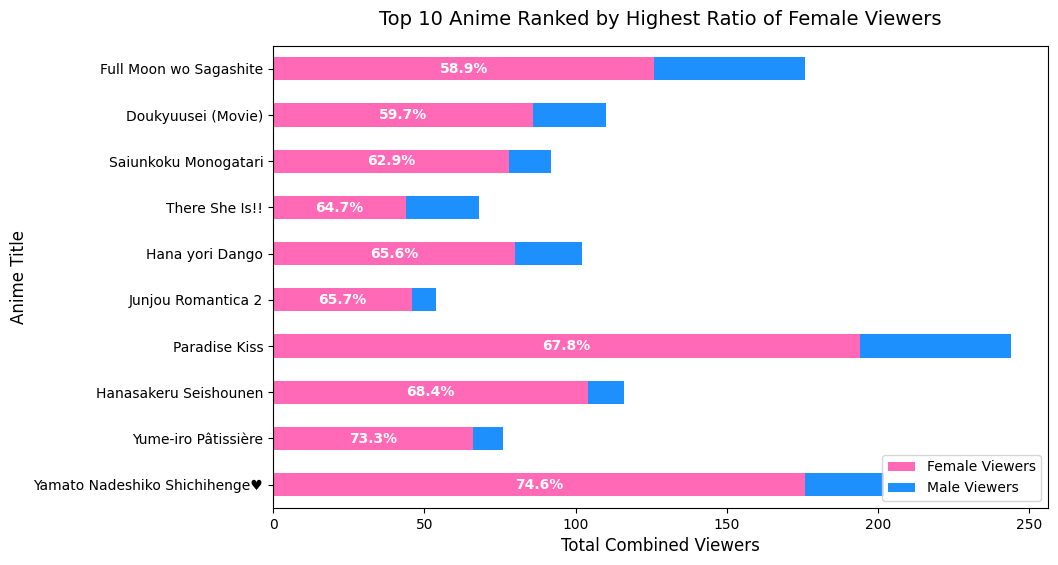

In [ ]:
# Second run

import matplotlib.pyplot as plt
import pandas as pd

# 1. Run query ordered specifically by the highest female ratio
query_ratio = """
SELECT
    a.title,
    SUM(CASE WHEN u.gender = 'Female' THEN 1 ELSE 0 END) AS Female_viewers,
    SUM(CASE WHEN u.gender = 'Male' THEN 1 ELSE 0 END) AS MaleViewer,
    (100.0 * SUM(CASE WHEN u.gender = 'Female' THEN 1 ELSE 0 END) / COUNT(u.profile)) AS female_ratio
FROM users_table u
JOIN reviews_table r ON u.profile = r.profile
JOIN anime_table a ON r.anime_uid = a.uid
GROUP BY a.title
HAVING (Female_viewers + MaleViewer) > 50
ORDER BY female_ratio DESC
LIMIT 10;
"""

df_ratio = pd.read_sql_query(query_ratio, conn)
df_ratio.set_index('title', inplace=True)

# 2. Create a clean horizontal stacked layout
ax = df_ratio[['Female_viewers', 'MaleViewer']].plot(
    kind='barh',
    stacked=True,
    color=['#FF69B5', '#1E90FD'],
    figsize=(10, 6)
)

# 3. Add text labels over the bars showing the precise ratio calculated by SQL
for i, ratio in enumerate(df_ratio['female_ratio']):
    ax.text(
        df_ratio['Female_viewers'].iloc[i] / 2,  # Places text roughly in the middle of the pink section
        i,
        f"{ratio:.1f}%",
        va='center',
        ha='center',
        color='white',
        fontweight='bold'
    )

ax.set_title('Top 10 Anime Ranked by Highest Ratio of Female Viewers', fontsize=14, pad=15)
ax.set_xlabel('Total Combined Viewers', fontsize=12)
ax.set_ylabel('Anime Title', fontsize=12)
ax.legend(['Female Viewers', 'Male Viewers'], loc='lower right')

# 4. Export clean version for your GitHub layout
plt.savefig('anime_female_ratio_ranking.png', bbox_inches='tight', dpi=300)

In [ ]:
# Code to combine both vizualisations to make it feel as a Dashboards

import sqlite3
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ==========================================
# 1. DATA EXTRACTION via YOUR SQL QUERY
# ==========================================
sql_query = """
SELECT
    a.title,
    SUM(CASE WHEN u.gender = 'Female' THEN 1 ELSE 0 END) AS Female_viewers,
    SUM(CASE WHEN u.gender = 'Male' THEN 1 ELSE 0 END) AS MaleViewer,
    (100.0 * SUM(CASE WHEN u.gender = 'Female' THEN 1 ELSE 0 END) / COUNT(u.profile)) AS female_ratio
FROM users_table u
JOIN reviews_table r ON u.profile = r.profile
JOIN anime_table a ON r.anime_uid = a.uid
GROUP BY a.title
HAVING (Female_viewers + MaleViewer) > 0;
"""
df_all = pd.read_sql_query(sql_query, conn)

# Prep Data Subsets for Charts
df_top10_popular = df_all.assign(total=df_all['Female_viewers'] + df_all['MaleViewer']).sort_values(by='total', ascending=False).head(10)
# Filter for shows with a decent sample size before picking the highest ratio
df_high_ratio = df_all[df_all['Female_viewers'] + df_all['MaleViewer'] > 50]
df_top10_female = df_high_ratio.sort_values(by='female_ratio', ascending=False).head(10)

# Calculate Core KPI Metrics safely
total_tracked_reviews = int(df_all['Female_viewers'].sum() + df_all['MaleViewer'].sum())
overall_female_percent = float(df_all['Female_viewers'].sum() / total_tracked_reviews * 100) if total_tracked_reviews > 0 else 0.0

# Extract top record for KPI 3
top_female_record = df_top10_female.iloc[0] if not df_top10_female.empty else {"title": "N/A", "female_ratio": 0.0}
highest_female_ratio_val = float(top_female_record['female_ratio'])
highest_female_ratio_show = str(top_female_record['title'])

# ==========================================
# 2. CREATE DASHBOARD GRID LAYOUT
# ==========================================
fig = make_subplots(
    rows=3, cols=3,
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
        [{"type": "bar", "colspan": 3}, None, None],
        [{"type": "bar", "colspan": 3}, None, None]
    ],
    vertical_spacing=0.08,
    subplot_titles=(
        "", "", "",
        "<b>Top 10 Most Watched Anime Overall (Demographic Breakdown)</b>",
        "<b>Top 10 Anime Ranked by Female Viewer Percentage Ratio</b>"
    )
)

# ==========================================
# 3. ADD KPI CARDS (Row 1)
# ==========================================
# KPI 1: Total Volume
fig.add_trace(go.Indicator(
    mode="number", value=total_tracked_reviews,
    title={"text": "Total Sample Reviews Checked", "font": {"size": 13, "color": "#718096"}},
    number={"font": {"color": "#2D3748", "size": 38}},
), row=1, col=1)

# KPI 2: Overall Split
fig.add_trace(go.Indicator(
    mode="number", value=overall_female_percent,
    number={"suffix": "%", "valueformat": ".1f", "font": {"color": "#0c0d10", "size": 38}},
    title={"text": "Global Female Share", "font": {"size": 13, "color": "#0c0d10"}},
), row=1, col=2)

# KPI 3: Highest Specific Skew (Fixed text bug by moving text to title)
fig.add_trace(go.Indicator(
    mode="number", value=highest_female_ratio_val,
    number={"suffix": "%", "valueformat": ".1f", "font": {"color": "#FF69B4", "size": 38}},
    title={"text": f"Highest Skew: {highest_female_ratio_show[:18]}...", "font": {"size": 12, "color": "#718096"}},
), row=1, col=3)

# ==========================================
# 4. ADD CHARTS (Rows 2 & 3)
# ==========================================
# Row 2: Popularity side-by-side grouped tracking
fig.add_trace(go.Bar(
    x=df_top10_popular['title'], y=df_top10_popular['Female_viewers'],
    name='Female Viewers', marker_color='#FF69B4'
), row=2, col=1)

fig.add_trace(go.Bar(
    x=df_top10_popular['title'], y=df_top10_popular['MaleViewer'],
    name='Male Viewers', marker_color='#1E90FF'
), row=2, col=1)

# Row 3: Pure Ratio Horizontal tracking (Avoids layout-crashing stacked conflicts)
fig.add_trace(go.Bar(
    y=df_top10_female['title'], x=df_top10_female['female_ratio'],
    orientation='h', marker_color='#FF69B4', name='Female Ratio %',
    hovertemplate="Female Audience: %{x:.1f}%<extra></extra>"
), row=3, col=1)

# ==========================================
# 5. POLISH DASHBOARD LAYOUT
# ==========================================
fig.update_layout(
    title_text="<b>Anime Analytics Portfolio Dashboard</b>",
    title_font_size=24,
    barmode='group',
    height=950,
    template="plotly_white",
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=0.64, xanchor="right", x=1)
)

# Ensure the horizontal chart reads top-to-bottom logically
fig.update_yaxes(autorange="reversed", row=3, col=1)
fig.update_xaxes(title_text="Percentage (%)", range=[0, 100], row=3, col=1)
fig.update_xaxes(title_text="Review/Watch Volume", row=2, col=1)

fig.show()

In [ ]:
# add a more polished design
import sqlite3
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ==========================================
# 1. DATA EXTRACTION via YOUR SQL QUERY
# ==========================================
sql_query = """
SELECT
    a.title,
    SUM(CASE WHEN u.gender = 'Female' THEN 1 ELSE 0 END) AS Female_viewers,
    SUM(CASE WHEN u.gender = 'Male' THEN 1 ELSE 0 END) AS MaleViewer,
    (100.0 * SUM(CASE WHEN u.gender = 'Female' THEN 1 ELSE 0 END) / COUNT(u.profile)) AS female_ratio
FROM users_table u
JOIN reviews_table r ON u.profile = r.profile
JOIN anime_table a ON r.anime_uid = a.uid
GROUP BY a.title
HAVING (Female_viewers + MaleViewer) > 0;
"""
df_all = pd.read_sql_query(sql_query, conn)

# Prep Data Subsets for Charts
df_top10_popular = df_all.assign(total=df_all['Female_viewers'] + df_all['MaleViewer']).sort_values(by='total', ascending=False).head(10)
# Filter for shows with a decent sample size before picking the highest ratio
df_high_ratio = df_all[df_all['Female_viewers'] + df_all['MaleViewer'] > 50]
df_top10_female = df_high_ratio.sort_values(by='female_ratio', ascending=False).head(10)

# Calculate Core KPI Metrics safely
total_tracked_reviews = int(df_all['Female_viewers'].sum() + df_all['MaleViewer'].sum())
overall_female_percent = float(df_all['Female_viewers'].sum() / total_tracked_reviews * 100) if total_tracked_reviews > 0 else 0.0

# Extract top record for KPI 3
top_female_record = df_top10_female.iloc[0] if not df_top10_female.empty else {"title": "N/A", "female_ratio": 0.0}
highest_female_ratio_val = float(top_female_record['female_ratio'])
highest_female_ratio_show = str(top_female_record['title'])

# ==========================================
# 2. CREATE DASHBOARD GRID LAYOUT
# ==========================================
fig = make_subplots(
    rows=3, cols=3,
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
        [{"type": "bar", "colspan": 3}, None, None],
        [{"type": "bar", "colspan": 3}, None, None]
    ],
    vertical_spacing=0.08,
    subplot_titles=(
        "", "", "",
        "<b>Top 10 Most Watched Anime Overall (Demographic Breakdown)</b>",
        "<b>Top 10 Anime Ranked by Female Viewer Percentage Ratio</b>"
    )
)

# ==========================================
# 3. ADD KPI CARDS (Row 1)
# ==========================================
# KPI 1: Total Volume
fig.add_trace(go.Indicator(
    mode="number", value=total_tracked_reviews,
    title={"text": "Total Sample Reviews Checked", "font": {"size": 13, "color": "#718096"}},
    number={"font": {"color": "#2D3748", "size": 38}},
), row=1, col=1)

# KPI 2: Overall Split
fig.add_trace(go.Indicator(
    mode="number", value=overall_female_percent,
    number={"suffix": "%", "valueformat": ".1f", "font": {"color": "#E2E8F0", "size": 38}},
    title={"text": "Global Female Share", "font": {"size": 13, "color": "#718096"}},
), row=1, col=2)

# KPI 3: Highest Specific Skew (Fixed text bug by moving text to title)
fig.add_trace(go.Indicator(
    mode="number", value=highest_female_ratio_val,
    number={"suffix": "%", "valueformat": ".1f", "font": {"color": "#FF69B4", "size": 38}},
    title={"text": f"Highest Skew: {highest_female_ratio_show[:18]}...", "font": {"size": 12, "color": "#718096"}},
), row=1, col=3)

# ==========================================
# 4. ADD CHARTS (Rows 2 & 3)
# ==========================================
# Row 2: Popularity side-by-side grouped tracking
fig.add_trace(go.Bar(
    x=df_top10_popular['title'], y=df_top10_popular['Female_viewers'],
    name='Female Viewers', marker_color='#FF69B4'
), row=2, col=1)

fig.add_trace(go.Bar(
    x=df_top10_popular['title'], y=df_top10_popular['MaleViewer'],
    name='Male Viewers', marker_color='#1E90FF'
), row=2, col=1)

# Row 3: Pure Ratio Horizontal tracking (Avoids layout-crashing stacked conflicts)
fig.add_trace(go.Bar(
    y=df_top10_female['title'], x=df_top10_female['female_ratio'],
    orientation='h', marker_color='#FF69B4', name='Female Ratio %',
    hovertemplate="Female Audience: %{x:.1f}%<extra></extra>"
), row=3, col=1)

# ==========================================
# 5. POLISH DASHBOARD LAYOUT
# ==========================================
fig.update_layout(
    title_text="<b>Anime Analytics Portfolio Dashboard</b>",
    title_font_size=24,
    barmode='group',
    height=950,
    template="plotly_white",
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=0.64, xanchor="right", x=1)
)

# Ensure the horizontal chart reads top-to-bottom logically
fig.update_yaxes(autorange="reversed", row=3, col=1)
fig.update_xaxes(title_text="Percentage (%)", range=[0, 100], row=3, col=1)
fig.update_xaxes(title_text="Review/Watch Volume", row=2, col=1)

fig.show()